# Room-Temperature C-V Physical Modeling


In [1]:
# Import the C-V data, Cgd PINN, and physical capacitance equations.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from CV_DeviceData import load_cv_characteristics
from physics_loss import physics_loss
from CV_CgdSurfacePotential import DeltaPhiGdPINN, phi_gd_surface, save_cgd_pinn_pkl
from CVModeling import Cgd, Cds, Cgs, built_in_potential_4h_sic
from CVPhysicalModel import CVPhysicalParameters, save_cv_physical_pkl


## Data and constants

In [2]:
# Load the room-temperature low-voltage and 0-1000 V capacitance datasets.
device = torch.device("cpu")
dtype = torch.float32
torch.manual_seed(42)
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"
cv_data = load_cv_characteristics(TEMPLATE_DIR)
print(cv_data.groupby(["capacitance", "range"]).size())
print("Measured Vds range =", cv_data["Vds"].min(), "to", cv_data["Vds"].max(), "V")
assert np.allclose(cv_data["T_C"].to_numpy(), 25.0)


capacitance  range
Ciss         high     19
             low      23
Coss         high     31
             low      37
Crss         high     45
             low      52
dtype: int64
Measured Vds range = 0.0 to 999.9999999999998 V


In [3]:
# Use the room-temperature surface-potential and capacitance parameters as initial physical values.
T = 298.15
NA = 1.0e16
Eg = 3.26
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Qox = 1.602e-7
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Ec_minus_Ei = Eg / 2.0

VDG_MIN = 0.0
VDG_MAX = 1000.0
VDS_MIN = 0.0
VDS_MAX = 1000.0
CGD_PRETRAINED_PKL = BASE_DIR / "Cgd_PINN_pretrained.pkl"
CGD_PKL = BASE_DIR / "Cgd_PINN.pkl"
CV_PKL = BASE_DIR / "CV_physical_25C.pkl"


## Pretrain the room-temperature Cgd surface-potential PINN


In [4]:
# Train phi_gd at 25 C with Vgd = Vgs - Vds and Vds as the quasi-Fermi potential.
Model_Cgd = DeltaPhiGdPINN(VDG_MIN, VDG_MAX, VDS_MIN, VDS_MAX).to(device=device, dtype=dtype)

N_RANDOM = 7000

Vds_random = VDS_MAX * torch.rand(N_RANDOM, 1, dtype=dtype, device=device)
Vgd_random = VDG_MIN + (VDG_MAX - VDG_MIN) * torch.rand(N_RANDOM, 1, dtype=dtype, device=device)

Vds_line = torch.linspace(0.0, 1000.0, 1201, dtype=dtype, device=device).reshape(-1, 1)
Vgd_line = Vds_line

Vds_train = torch.cat([Vds_random, Vds_line], dim=0)
Vgd_train = torch.cat([Vgd_random, Vgd_line], dim=0)

N_TRAIN = len(Vds_train)

EPOCHS_GD = 3000
BATCH_SIZE_GD = 512
LEARNING_RATE_GD = 1.0e-4

optimizer_gd = torch.optim.Adam(Model_Cgd.parameters(), lr=LEARNING_RATE_GD)

best_loss_gd = float("inf")
best_state_gd = None
loss_gd_history = []

for epoch in range(EPOCHS_GD):
    permutation = torch.randperm(N_TRAIN, device=device)
    epoch_loss = 0.0
    batches = 0

    Model_Cgd.train()

    for start in range(0, N_TRAIN, BATCH_SIZE_GD):
        idx = permutation[start:start + BATCH_SIZE_GD]

        Vgd_batch = Vgd_train[idx]
        Vds_batch = Vds_train[idx]

        optimizer_gd.zero_grad(set_to_none=True)

        phigd = phi_gd_surface(Model_Cgd, Vgd_batch, Vds_batch, T=T, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg, Qox=Qox)

        loss = physics_loss(phigd, Vgd_batch, Vds_batch, T, NA, eps_sic, Cox, Vfbs0, Qox, Dit_mid, Dit_edge, sigma_it, Ec_minus_Ei, Eg)

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite Cgd PINN loss at epoch {epoch}")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(Model_Cgd.parameters(), max_norm=10.0)

        optimizer_gd.step()

        epoch_loss += loss.item()
        batches += 1

    epoch_loss /= batches
    loss_gd_history.append(epoch_loss)

    if epoch_loss < best_loss_gd:
        best_loss_gd = epoch_loss
        best_state_gd = {k: v.detach().cpu().clone() for k, v in Model_Cgd.state_dict().items()}

    if epoch % 100 == 0 or epoch == EPOCHS_GD - 1:
        print(f"Cgd PINN epoch {epoch:4d} | L_SPE = {epoch_loss:.6e}")

Model_Cgd.load_state_dict(best_state_gd, strict=True)
Model_Cgd.eval()

# Freeze the trained Cgd surface-potential PINN.
for parameter in Model_Cgd.parameters():
    parameter.requires_grad_(False)

save_cgd_pinn_pkl(CGD_PRETRAINED_PKL, Model_Cgd, physical_parameters={"T_K": T, "NA": NA, "Cox": Cox, "Qox": Qox, "Vfbs0": Vfbs0, "Dit_mid": Dit_mid, "Dit_edge": Dit_edge, "sigma_it": sigma_it, "Eg": Eg}, training_metadata={"best_PI_loss": best_loss_gd, "epochs": EPOCHS_GD})

print("Saved =", CGD_PRETRAINED_PKL.name)

Cgd PINN epoch    0 | L_SPE = 5.773723e+03
Cgd PINN epoch  100 | L_SPE = 2.407395e+02
Cgd PINN epoch  200 | L_SPE = 1.348037e+02
Cgd PINN epoch  300 | L_SPE = 6.736004e+01
Cgd PINN epoch  400 | L_SPE = 6.143373e+01
Cgd PINN epoch  500 | L_SPE = 5.784127e+01
Cgd PINN epoch  600 | L_SPE = 6.262276e+01
Cgd PINN epoch  700 | L_SPE = 5.087789e+01
Cgd PINN epoch  800 | L_SPE = 4.797194e+01
Cgd PINN epoch  900 | L_SPE = 4.633652e+01
Cgd PINN epoch 1000 | L_SPE = 4.440397e+01
Cgd PINN epoch 1100 | L_SPE = 4.129013e+01
Cgd PINN epoch 1200 | L_SPE = 4.108247e+01
Cgd PINN epoch 1300 | L_SPE = 3.904314e+01
Cgd PINN epoch 1400 | L_SPE = 3.706680e+01
Cgd PINN epoch 1500 | L_SPE = 3.701731e+01
Cgd PINN epoch 1600 | L_SPE = 3.048976e+01
Cgd PINN epoch 1700 | L_SPE = 2.822257e+01
Cgd PINN epoch 1800 | L_SPE = 2.611449e+01
Cgd PINN epoch 1900 | L_SPE = 3.023792e+01
Cgd PINN epoch 2000 | L_SPE = 2.145898e+01
Cgd PINN epoch 2100 | L_SPE = 1.721022e+01
Cgd PINN epoch 2200 | L_SPE = 1.589416e+01
Cgd PINN ep

## Decoupling Cgd and Cds, making Ads respectively compensate 1cell

In [5]:
# Build measured Cgd and Cds targets.

crss_ref = cv_data[cv_data["capacitance"] == "Crss"].groupby("Vds", as_index=False)["Capacitance_pF"].mean().sort_values("Vds")
coss_ref = cv_data[cv_data["capacitance"] == "Coss"].groupby("Vds", as_index=False)["Capacitance_pF"].mean().sort_values("Vds")

Vds_cgd_np = crss_ref["Vds"].to_numpy(np.float32)
Cgd_target_np = crss_ref["Capacitance_pF"].to_numpy(np.float32)

Vds_cds_np = coss_ref["Vds"].to_numpy(np.float32)
Coss_target_np = coss_ref["Capacitance_pF"].to_numpy(np.float32)
Crss_interp_np = np.interp(Vds_cds_np, Vds_cgd_np, Cgd_target_np)
Cds_target_np = np.clip(Coss_target_np - Crss_interp_np, 1.0e-3, None)

Vds_cgd = torch.tensor(Vds_cgd_np, dtype=dtype, device=device).reshape(-1, 1)
Cgd_target_pF = torch.tensor(Cgd_target_np, dtype=dtype, device=device).reshape(-1, 1)
Vds_cds = torch.tensor(Vds_cds_np, dtype=dtype, device=device).reshape(-1, 1)
Cds_target_pF = torch.tensor(Cds_target_np, dtype=dtype, device=device).reshape(-1, 1)

print("Cgd target points =", len(Vds_cgd))
print("Cds target points =", len(Vds_cds))

Cgd target points = 86
Cds target points = 67


## Fit the room-temperature physical C-V parameters with automatic differentiation


In [6]:
# Convert all measured capacitance points to tensors and type labels.
Vds_data = torch.tensor(cv_data["Vds"].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)
C_measured_pF = torch.tensor(cv_data["Capacitance_pF"].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)
cap_codes = {"Ciss": 0, "Coss": 1, "Crss": 2}
cap_type = torch.tensor([cap_codes[name] for name in cv_data["capacitance"]], dtype=torch.long, device=device).reshape(-1, 1)
cv_parameters = CVPhysicalParameters(ND=3.923357e16, Agd_init=3.1e-3, Ads_init=0.03735269, Coxgd_init=1.0e-9, Cgs_init=1100e-12, Vpt_init=523.0919).to(device=device, dtype=dtype)
print("Initial physical parameters =", cv_parameters.report(Cox))

Initial physical parameters = {'ND': 3.923357276622029e+16, 'Agd': 0.003099999390542507, 'Ads': 0.03735268861055374, 'Coxgd': 9.999991945619513e-10, 'Cgs_const': 1.0999992028359884e-09, 'Vpt': 523.0918579101562}


In [7]:
def evaluate_cv(Vds):
    values = cv_parameters.values(Cox)

    Vds_cgd = torch.clamp(Vds, min=0.0)
    Vgd_cgd = Vds_cgd

    phigd = phi_gd_surface(Model_Cgd, Vgd_cgd, Vds_cgd, T=T, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg, Qox=Qox)

    Vbi = built_in_potential_4h_sic(T, NA, values["ND"], Eg, Vds)

    Cgd_value = Cgd(phigd, Vds_cgd, T, NA, values["ND"], Eg, eps_sic, values["Agd"], values["Coxgd"])
    Cds_value = Cds(Vds, values["ND"], eps_sic, values["Ads"], Vbi, values["Vpt"])
    Cgs_value = Cgs(Vds, values["Cgs_const"])

    Ciss = Cgs_value + Cgd_value
    Coss = Cds_value + Cgd_value
    Crss = Cgd_value

    return Ciss, Coss, Crss, phigd, Vgd_cgd

In [8]:
# Evaluate the C-V model without additional neural-network training.

Model_Cgd.eval()
cv_parameters.eval()

with torch.no_grad():
    Ciss, Coss, Crss, phigd, Vgd_eff = evaluate_cv(Vds_data)

    all_pred_pF = torch.cat([Ciss * 1.0e12, Coss * 1.0e12, Crss * 1.0e12], dim=1)
    C_pred_pF = torch.gather(all_pred_pF, 1, cap_type)

    data_loss = torch.mean((torch.log(torch.clamp(C_pred_pF, min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF, min=1.0e-3))) ** 2)

print("C-V data loss =", data_loss.item())
print({k: float(v.item()) if torch.is_tensor(v) else v for k, v in cv_parameters.values(Cox).items()})

C-V data loss = 0.30639368295669556
{'ND': 3.923357276622029e+16, 'Agd': 0.003099999390542507, 'Ads': 0.03735268861055374, 'Coxgd': 9.999991945619513e-10, 'Cgs_const': 1.0999992028359884e-09, 'Vpt': 523.0918579101562}


## Check 1cell

In [9]:
# Evaluate the physics residual along the actual C-V operating line.
with torch.no_grad():
    phigd_cv = phi_gd_surface(Model_Cgd, Vds_line, Vds_line, T=T, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg, Qox=Qox)
    loss_cv_line = physics_loss(phigd_cv, Vds_line, Vds_line, T, NA, eps_sic, Cox, Vfbs0, Qox, Dit_mid, Dit_edge, sigma_it, Ec_minus_Ei, Eg)

print("Global best L_SPE =", best_loss_gd)
print("Global RMS residual =", best_loss_gd ** 0.5, "V")
print("C-V line L_SPE =", loss_cv_line.item())
print("C-V line RMS residual =", loss_cv_line.item() ** 0.5, "V")

Global best L_SPE = 9.04977648749071
Global RMS residual = 3.0082846420328497 V
C-V line L_SPE = 0.09050200134515762
C-V line RMS residual = 0.3008355054596409 V


## Optimize ND and Vpt with the frozen surface-potential PINN


In [10]:
# Optimize Coxgd against Crss with the Cgd PINN frozen.
for parameter in Model_Cgd.parameters():
    parameter.requires_grad_(False)

for parameter in cv_parameters.parameters():
    parameter.requires_grad_(False)

cv_parameters.log_Coxgd.requires_grad_(True)

EPOCHS_JOINT = 3000
LEARNING_RATE_PHYS = 1.0e-4
LOSS_REFERENCE_MIN = 1.0e-6

# Calculate the initial per-curve loss references for normalization.
with torch.no_grad():
    Ciss_ref, Coss_ref, Crss_ref, _, _ = evaluate_cv(Vds_data)
    all_ref_pF = torch.cat([Ciss_ref * 1.0e12, Coss_ref * 1.0e12, Crss_ref * 1.0e12], dim=1)
    ciss_mask = cap_type.reshape(-1) == 0
    coss_mask = cap_type.reshape(-1) == 1
    crss_mask = cap_type.reshape(-1) == 2
    CISS_LOSS_REFERENCE = max(float(torch.mean((torch.log(torch.clamp(all_ref_pF[ciss_mask, 0], min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF.reshape(-1)[ciss_mask], min=1.0e-3))) ** 2).item()), LOSS_REFERENCE_MIN)
    COSS_LOSS_REFERENCE = max(float(torch.mean((torch.log(torch.clamp(all_ref_pF[coss_mask, 1], min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF.reshape(-1)[coss_mask], min=1.0e-3))) ** 2).item()), LOSS_REFERENCE_MIN)
    CRSS_LOSS_REFERENCE = max(float(torch.mean((torch.log(torch.clamp(all_ref_pF[crss_mask, 2], min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF.reshape(-1)[crss_mask], min=1.0e-3))) ** 2).item()), LOSS_REFERENCE_MIN)

print("Initial loss references =", {"Ciss": CISS_LOSS_REFERENCE, "Coss": COSS_LOSS_REFERENCE, "Crss": CRSS_LOSS_REFERENCE})

optimizer_joint = torch.optim.Adam([cv_parameters.log_Coxgd], lr=LEARNING_RATE_PHYS)
joint_loss_history = []
joint_data_history = []
best_joint_loss = float("inf")
best_joint_cv_state = None

print("Trainable Cgd parameters =", [name for name, parameter in Model_Cgd.named_parameters() if parameter.requires_grad])
print("Trainable C-V parameters =", [name for name, parameter in cv_parameters.named_parameters() if parameter.requires_grad])

for epoch in range(EPOCHS_JOINT):
    optimizer_joint.zero_grad(set_to_none=True)

    Ciss_joint, Coss_joint, Crss_joint, _, _ = evaluate_cv(Vds_data)
    all_pred_pF = torch.cat([Ciss_joint * 1.0e12, Coss_joint * 1.0e12, Crss_joint * 1.0e12], dim=1)

    loss_ciss = torch.mean((torch.log(torch.clamp(all_pred_pF[ciss_mask, 0], min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF.reshape(-1)[ciss_mask], min=1.0e-3))) ** 2)
    loss_coss = torch.mean((torch.log(torch.clamp(all_pred_pF[coss_mask, 1], min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF.reshape(-1)[coss_mask], min=1.0e-3))) ** 2)
    loss_crss = torch.mean((torch.log(torch.clamp(all_pred_pF[crss_mask, 2], min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF.reshape(-1)[crss_mask], min=1.0e-3))) ** 2)

    loss_ciss_norm = loss_ciss / CISS_LOSS_REFERENCE
    loss_coss_norm = loss_coss / COSS_LOSS_REFERENCE
    loss_crss_norm = loss_crss / CRSS_LOSS_REFERENCE
    loss_data = (loss_ciss_norm + loss_coss_norm + loss_crss_norm) / 3.0
    loss = loss_crss

    if not torch.isfinite(loss):
        raise RuntimeError(f"Non-finite C-V parameter loss at epoch {epoch}")

    loss.backward()
    torch.nn.utils.clip_grad_norm_([cv_parameters.log_Coxgd], max_norm=5.0)
    optimizer_joint.step()

    with torch.no_grad():
        cv_parameters.log_ND.clamp_(np.log(1.0e15), np.log(5.0e17))
        cv_parameters.log_Vpt.clamp_(np.log(1.0), np.log(VDS_MAX))

    joint_loss_history.append(loss.item())
    joint_data_history.append(loss_data.item())

    if loss.item() < best_joint_loss:
        best_joint_loss = loss.item()
        best_joint_cv_state = {key: value.detach().cpu().clone() for key, value in cv_parameters.state_dict().items()}

    if epoch % 100 == 0 or epoch == EPOCHS_JOINT - 1:
        values = cv_parameters.report(Cox)
        print(f"C-V epoch {epoch:4d} | total = {loss.item():.6e} | Ciss = {loss_ciss_norm.item():.6e} | Coss = {loss_coss_norm.item():.6e} | Crss = {loss_crss_norm.item():.6e} | Coxgd = {values['Coxgd']:.6e}")

cv_parameters.load_state_dict(best_joint_cv_state, strict=True)

Model_Cgd.eval()
cv_parameters.eval()

with torch.no_grad():
    Ciss, Coss, Crss, phigd, Vgd_eff = evaluate_cv(Vds_data)
    all_pred_pF = torch.cat([Ciss * 1.0e12, Coss * 1.0e12, Crss * 1.0e12], dim=1)
    C_pred_pF = torch.gather(all_pred_pF, 1, cap_type)
    data_loss = torch.mean((torch.log(torch.clamp(C_pred_pF, min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF, min=1.0e-3))) ** 2)

print("Best C-V parameter loss =", best_joint_loss)
print("Final physical parameters =", cv_parameters.report(Cox))
print("Final C-V data loss =", data_loss.item())

for parameter in [cv_parameters.log_Coxgd]:
    parameter.requires_grad_(False)


Initial loss references = {'Ciss': 0.01660734787583351, 'Coss': 0.031089618802070618, 'Crss': 0.6248647570610046}
Trainable Cgd parameters = []
Trainable C-V parameters = ['log_Coxgd']
C-V epoch    0 | total = 6.248648e-01 | Ciss = 1.000000e+00 | Coss = 1.000000e+00 | Crss = 1.000000e+00 | Coxgd = 1.000098e-09
C-V epoch  100 | total = 6.244460e-01 | Ciss = 9.996184e-01 | Coss = 9.998238e-01 | Crss = 9.993298e-01 | Coxgd = 1.010067e-09
C-V epoch  200 | total = 6.240314e-01 | Ciss = 9.992402e-01 | Coss = 9.996478e-01 | Crss = 9.986663e-01 | Coxgd = 1.020135e-09
C-V epoch  300 | total = 6.236210e-01 | Ciss = 9.988652e-01 | Coss = 9.994748e-01 | Crss = 9.980096e-01 | Coxgd = 1.030303e-09
C-V epoch  400 | total = 6.232145e-01 | Ciss = 9.984936e-01 | Coss = 9.993026e-01 | Crss = 9.973591e-01 | Coxgd = 1.040571e-09
C-V epoch  500 | total = 6.228200e-01 | Ciss = 9.981312e-01 | Coss = 9.991351e-01 | Crss = 9.967277e-01 | Coxgd = 1.050742e-09
C-V epoch  600 | total = 6.224293e-01 | Ciss = 9.9777

## Check which params are trained


In [11]:
# Check that the jointly fitted parameters are frozen after training.

print("Trainable Cgd parameters:", [name for name, parameter in Model_Cgd.named_parameters() if parameter.requires_grad])
print("Trainable C-V physical parameters:", [name for name, parameter in cv_parameters.named_parameters() if parameter.requires_grad])

Trainable Cgd parameters: []
Trainable C-V physical parameters: []


## Save the final Cgd PINN and room-temperature C-V physical parameters


In [12]:
# Save the final Cgd PINN and physical C-V parameters as pkl files.

save_cgd_pinn_pkl(CGD_PKL, Model_Cgd, physical_parameters={"T_K": T, "NA": NA, "Cox": Cox, "Qox": Qox, "Vfbs0": Vfbs0, "Dit_mid": Dit_mid, "Dit_edge": Dit_edge, "sigma_it": sigma_it, "Eg": Eg}, training_metadata={"temperature_C": 25.0, "best_PI_loss": best_loss_gd, "epochs": EPOCHS_GD})

save_cv_physical_pkl(CV_PKL, cv_parameters, training_metadata={"temperature_C": 25.0, "data_loss": float(data_loss.item()), "optimized_parameters": ["ND", "Vpt"], "best_parameter_loss": best_joint_loss})

cv_bundle = {"format_version": 2, "model_name": "SiC_MOSFET_CV_25C", "temperature_C": 25.0, "Cgd_surface_PINN": torch.load(CGD_PKL, map_location="cpu", weights_only=False), "CV_physical": torch.load(CV_PKL, map_location="cpu", weights_only=False)}

torch.save(cv_bundle, BASE_DIR / "CV_Model_25C.pkl")

print("Saved Cgd_PINN.pkl, CV_physical_25C.pkl, and CV_Model_25C.pkl")


Saved Cgd_PINN.pkl, CV_physical_25C.pkl, and CV_Model_25C.pkl


## Room-temperature C-V comparison


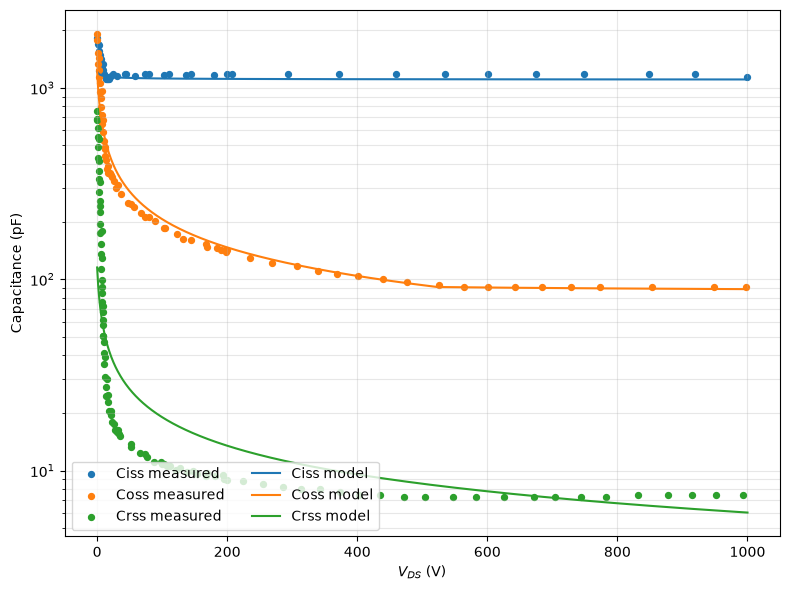

In [13]:
# Compare the fitted room-temperature Ciss, Coss, and Crss curves with both measured voltage ranges.
Vds_plot = torch.linspace(0.0, 1000.0, 1200, dtype=dtype, device=device).reshape(-1, 1)
Model_Cgd.eval()
cv_parameters.eval()
with torch.no_grad():
    Ciss_plot, Coss_plot, Crss_plot, _, _ = evaluate_cv(Vds_plot)

plt.figure(figsize=(8, 6))
for name in ["Ciss", "Coss", "Crss"]:
    part = cv_data[cv_data["capacitance"] == name]
    plt.scatter(part["Vds"], part["Capacitance_pF"], s=18, label=f"{name} measured")
for values, name in [(Ciss_plot, "Ciss model"), (Coss_plot, "Coss model"), (Crss_plot, "Crss model")]:
    plt.plot(Vds_plot.cpu(), (values * 1.0e12).cpu(), label=name)
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel("Capacitance (pF)")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


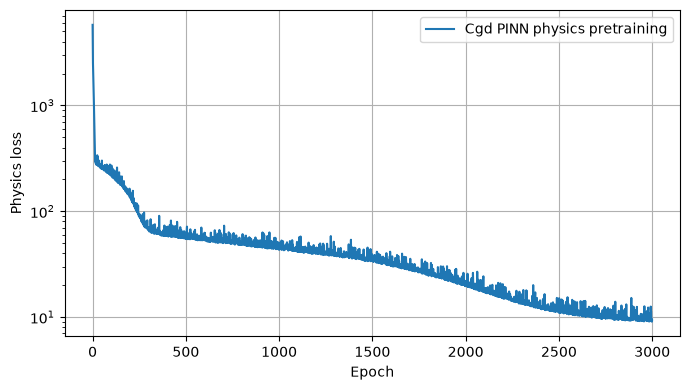

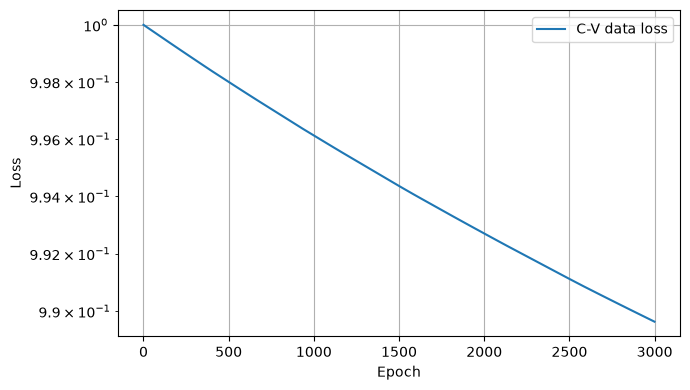

In [14]:
# Plot the physics pretraining and C-V parameter optimization losses.
plt.figure(figsize=(7, 4))
plt.plot(loss_gd_history, label="Cgd PINN physics pretraining")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Physics loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(joint_data_history, label="C-V data loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


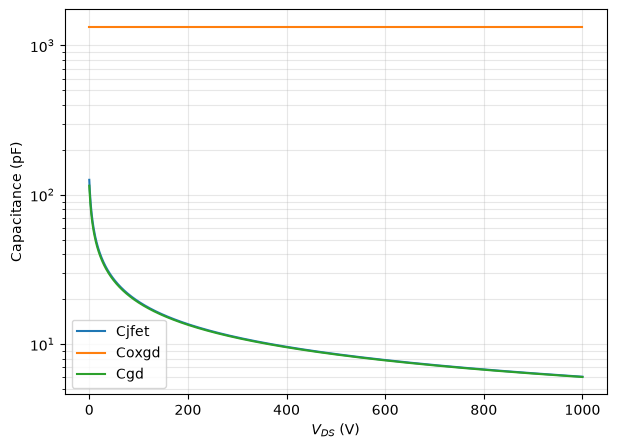

In [19]:
from CVModeling import *

# Inspect which capacitance limits Cgd along the C-V operating line.
Vds_diag = torch.linspace(0.0, 1000.0, 1000, dtype=dtype, device=device).reshape(-1, 1)

with torch.no_grad():
    values = cv_parameters.values(Cox)

    phigd_diag = phi_gd_surface(Model_Cgd, Vds_diag, Vds_diag, T=T, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg, Qox=Qox)

    Cjfet_diag = Cjfet(phigd_diag, Vds_diag, T, NA, values["ND"], Eg, eps_sic, values["Agd"])
    Cgd_diag = Cgd(phigd_diag, Vds_diag, T, NA, values["ND"], Eg, eps_sic, values["Agd"], values["Coxgd"])
    Coxgd_diag = torch.ones_like(Cjfet_diag) * values["Coxgd"]

plt.figure(figsize=(7, 5))
plt.semilogy(Vds_diag.cpu(), Cjfet_diag.cpu() * 1.0e12, label="Cjfet")
plt.semilogy(Vds_diag.cpu(), Coxgd_diag.cpu() * 1.0e12, label="Coxgd")
plt.semilogy(Vds_diag.cpu(), Cgd_diag.cpu() * 1.0e12, label="Cgd")
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel("Capacitance (pF)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [17]:
for voltage in [10.0, 50.0, 100.0, 200.0, 500.0, 1000.0]:
    idx = torch.argmin(torch.abs(Vds_diag.reshape(-1) - voltage))

    print(
        f"Vds = {voltage:6.1f} V | "
        f"Cjfet = {Cjfet_diag[idx].item() * 1e12:10.3f} pF | "
        f"Coxgd = {Coxgd_diag[idx].item() * 1e12:10.3f} pF | "
        f"Cgd = {Cgd_diag[idx].item() * 1e12:10.3f} pF"
    )

Vds =   10.0 V | Cjfet =     56.836 pF | Coxgd =   1329.832 pF | Cgd =     54.506 pF
Vds =   50.0 V | Cjfet =     27.146 pF | Coxgd =   1329.832 pF | Cgd =     26.603 pF
Vds =  100.0 V | Cjfet =     19.263 pF | Coxgd =   1329.832 pF | Cgd =     18.988 pF
Vds =  200.0 V | Cjfet =     13.611 pF | Coxgd =   1329.832 pF | Cgd =     13.473 pF
Vds =  500.0 V | Cjfet =      8.591 pF | Coxgd =   1329.832 pF | Cgd =      8.536 pF
Vds = 1000.0 V | Cjfet =      6.058 pF | Coxgd =   1329.832 pF | Cgd =      6.030 pF


Vds =   10.0 V | phigd =     7.6916 V | G = 1.0000e+00 | H = 2.7687e+00 | G/H = 3.6117e-01
Vds =   50.0 V | phigd =    33.6308 V | G = 1.0000e+00 | H = 5.7970e+00 | G/H = 1.7250e-01
Vds =  100.0 V | phigd =    66.7609 V | G = 1.0000e+00 | H = 8.1692e+00 | G/H = 1.2241e-01
Vds =  200.0 V | phigd =   133.6959 V | G = 1.0000e+00 | H = 1.1562e+01 | G/H = 8.6493e-02
Vds =  500.0 V | phigd =   335.5137 V | G = 1.0000e+00 | H = 1.8316e+01 | G/H = 5.4596e-02
Vds = 1000.0 V | phigd =   674.8684 V | G = 1.0000e+00 | H = 2.5978e+01 | G/H = 3.8495e-02


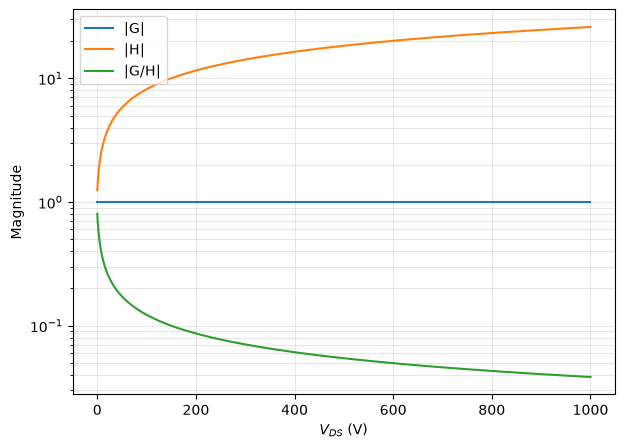

In [20]:
from CVModeling import *
from Residual import H_phis, phi_fermi

# Inspect the voltage dependence of G, H, and G/H.
q = torch.tensor(1.602176634e-19, dtype=dtype, device=device)
k_B = torch.tensor(1.380649e-23, dtype=dtype, device=device)
phi_t = k_B * T / q
phi_Fermi = phi_fermi(T, NA, Eg, ref=phigd_diag)

with torch.no_grad():
    G_diag = G_phigd(phigd_diag, Vds_diag, T, NA, Eg)
    H_diag = H_phis(phigd_diag, phi_t, phi_Fermi, Vds_diag)
    GH_diag = G_diag / torch.clamp(H_diag, min=1.0e-15)

for voltage in [10.0, 50.0, 100.0, 200.0, 500.0, 1000.0]:
    idx = torch.argmin(torch.abs(Vds_diag.reshape(-1) - voltage))

    print(
        f"Vds = {voltage:6.1f} V | "
        f"phigd = {phigd_diag[idx].item():10.4f} V | "
        f"G = {G_diag[idx].item():10.4e} | "
        f"H = {H_diag[idx].item():10.4e} | "
        f"G/H = {GH_diag[idx].item():10.4e}"
    )

plt.figure(figsize=(7, 5))
plt.semilogy(Vds_diag.cpu(), torch.abs(G_diag).cpu(), label="|G|")
plt.semilogy(Vds_diag.cpu(), torch.abs(H_diag).cpu(), label="|H|")
plt.semilogy(Vds_diag.cpu(), torch.abs(GH_diag).cpu(), label="|G/H|")
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel("Magnitude")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()